In [1]:
import numpy as np 
import tensorflow as tf
import pandas as pd 
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

In [2]:
data = tf.keras.utils.image_dataset_from_directory('data/')

Found 2041 files belonging to 2 classes.


In [3]:
class_names = data.class_names
class_names

['fake', 'real']

In [4]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

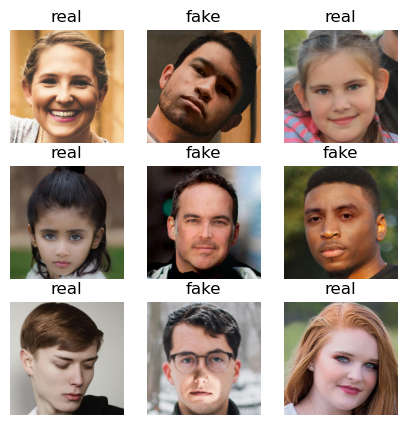

In [5]:
plt.figure(figsize=(5, 5))
for images, labels in data.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [6]:
data = data.map(lambda x,y: (x/255, y)) # x/255
data.as_numpy_iterator().next()

(array([[[[0.2628064 , 0.3403732 , 0.4488492 ],
          [0.26270393, 0.337275  , 0.44178826],
          [0.2577541 , 0.32570753, 0.42509478],
          ...,
          [0.9460449 , 0.8480057 , 0.7264371 ],
          [0.9373162 , 0.83927697, 0.71770835],
          [0.9285472 , 0.830508  , 0.7102261 ]],
 
         [[0.2523897 , 0.34264705, 0.47095588],
          [0.2550848 , 0.3452206 , 0.47089365],
          [0.25200003, 0.33447552, 0.456228  ],
          ...,
          [0.94397306, 0.84593385, 0.72436523],
          [0.9373765 , 0.8393373 , 0.71776867],
          [0.92685837, 0.8288191 , 0.7085373 ]],
 
         [[0.26093462, 0.36273935, 0.5209894 ],
          [0.26421568, 0.36468863, 0.5154412 ],
          [0.25349265, 0.34901962, 0.49905217],
          ...,
          [0.94258577, 0.84454656, 0.72297794],
          [0.9397892 , 0.84174997, 0.72018135],
          [0.928125  , 0.8300858 , 0.70980394]],
 
         ...,
 
         [[0.23235294, 0.27643707, 0.28238645],
          [0.23641

In [7]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [8]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten, Reshape
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers

resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

for layer in resnet_model.layers:
    layer.trainable = False

model = Sequential()
model.add(resnet_model)
model.add(layers.GlobalAveragePooling2D())
model.add(Reshape((1, -1))) 
model.add(LSTM(128))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
loss = 'binary_crossentropy'
model.compile(loss=loss, optimizer='adam', metrics=["accuracy"])


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 8, 8, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 1, 2048)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │       1,114,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,702,465 (94.23 MB)

 Trainable params: 1,114,753 (4.25 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
logdir='logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
hist = model.fit(train, epochs=5, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/5


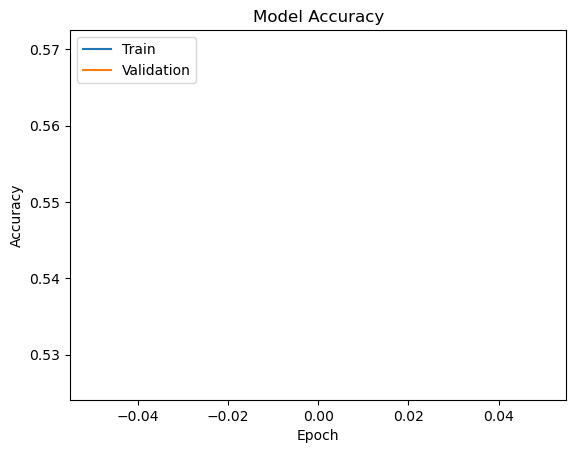

In [16]:
import matplotlib.pyplot as plt

# Assuming you have the 'history' object from model.fit
history = hist.history

# Plot training & validation accuracy values
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


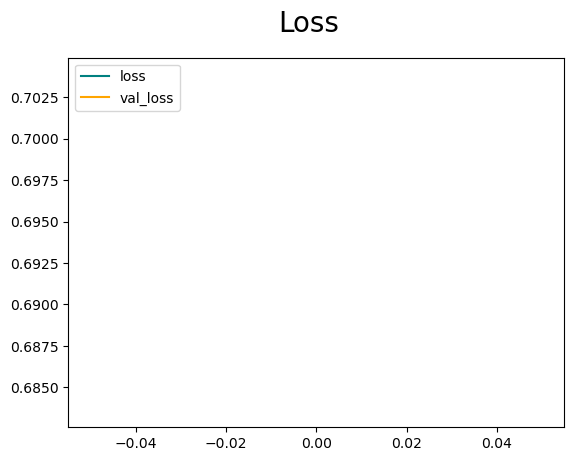

In [14]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

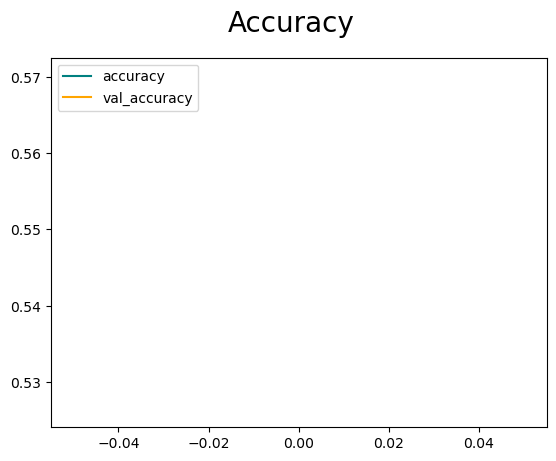

In [15]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test)

In [ ]:
print("Loss: ", loss)
print("Accuracy: ", accuracy)